# Multidimensional Regression with NNs 

We want to approximate the following unkown (multidimensional scalar real-valued) function $f\colon D \subset \mathbb{R}^d \rightarrow \mathbb{R}$ with a neural network model given input-output $K$ pairs $(x^{(k)}, y^{(k)})_{k=1}^K$ of the data. 

In [6]:
import sys; sys.path.append('../src/playground_jax')
from time import time

import jax
from jax import numpy as jnp
from jaxtyping import Array, PyTree
import equinox as eqx
import optax
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

from models_equinox import MLP

Define *target function*. For instance, $(x_1, x_2) \mapsto f(x_1, x_2) = x_1^2 + x_2^2$

In [7]:
def f_fn(x1, x2):
    return x1**2 + x2**2

Get training data by using the discretized 2-dimensional grid as the input

In [8]:
# set n points per axis
N = 101

# set bounds
x_min, x_max = -1, 1

# create grid
x1 = x2 = jnp.linspace(x_min, x_max, N)
x1_mesh, x2_mesh = jnp.meshgrid(x1, x2, indexing='ij')
x = jnp.stack((x1_mesh, x2_mesh))
x = jnp.moveaxis(x, 0, -1)
x_train = jnp.reshape(x, (N*N, 2))
    
# evaluate on grid
y = f_fn(x1_mesh, x2_mesh)
y_train = jnp.reshape(y, (N*N, 1))

Visualize the target function

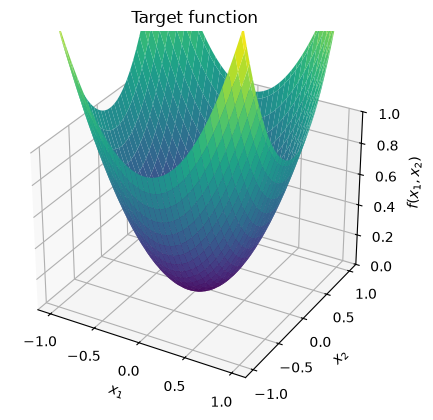

In [9]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(x1_mesh, x2_mesh, y_train.reshape(x1_mesh.shape), cmap='viridis')
ax.set_zlim(0,1)
ax.set_xlabel('$x_1$',fontsize=10)
ax.set_ylabel('$x_2$',fontsize=10)
ax.set_zlabel('$f(x_1,x_2)$',fontsize=10)
ax.set_title('Target function');

Build a model

In [11]:
# set a random key
key = jax.random.PRNGKey(1)

# define model
d_in, d_hiddens, d_out = 2, [32, 16, 8], 1
model = MLP(d_in, d_out, d_hiddens, jax.nn.tanh, lambda x: x, key=key)

Define MSE loss

In [16]:
def loss_fn(model, x, y):
    pred_y = jax.vmap(model, in_axes=0, out_axes=0)(x)
    return jnp.mean((y - pred_y) ** 2)

Define train step function method

In [17]:
@eqx.filter_jit
def train_step(model, opt_state: PyTree, x: Array, y: Array):
    
    # compute gradients and loss value
    loss_value, grads = eqx.filter_value_and_grad(loss_fn)(model, x, y)

    # compute the updates following the chosen optimizer's rule
    updates, opt_state = opt.update(grads, opt_state)

    # updates parameters
    model = eqx.apply_updates(model, updates)
    
    return model, opt_state, loss_value

Choose optimizer

In [18]:
lr = 1e-3
opt = optax.adam(learning_rate=lr)
opt_state = opt.init(eqx.filter(model, eqx.is_array))

Train

In [19]:
n_iter = int(1e4)
log_period_iter = int(1e3)
for i in range(n_iter):
    t0 = time()
    model, opt_state, loss_value = train_step(model, opt_state, x_train, y_train)
    t1 = time()
    if i % log_period_iter  == 0: 
        print('it: {:d}, loss: {:.3e}, time: {:.4f}s'.format(i, loss_value, t1-t0))

it: 0, loss: 1.384e+00, time: 0.2845s
it: 1000, loss: 1.419e-03, time: 0.0013s
it: 2000, loss: 3.473e-04, time: 0.0015s
it: 3000, loss: 1.148e-04, time: 0.0013s
it: 4000, loss: 4.582e-05, time: 0.0014s
it: 5000, loss: 2.610e-05, time: 0.0014s
it: 6000, loss: 1.756e-05, time: 0.0013s
it: 7000, loss: 1.300e-05, time: 0.0012s
it: 8000, loss: 1.022e-05, time: 0.0013s
it: 9000, loss: 8.419e-06, time: 0.0014s


Evaluate trained model

In [21]:
y_pred = jax.vmap(model, in_axes=0, out_axes=0)(x_train)


Compute _r2 score_

In [22]:
r2 = round(float(r2_score(y_train, y_pred)), 4)
print("R^2 Score:", r2)

R^2 Score: 0.9997


Visualize target function $f$ and trained MLP model $\varphi_\theta$

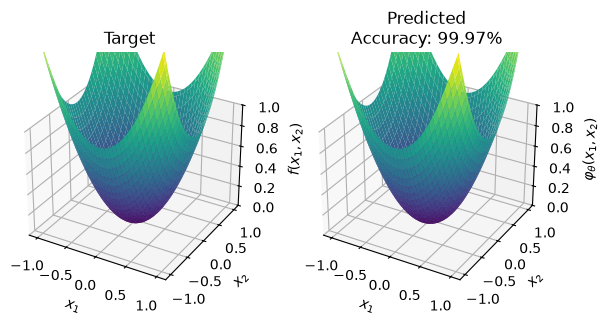

In [23]:
fig = plt.figure()

# Target function
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(x1_mesh, x2_mesh, y_train.reshape(x1_mesh.shape), cmap='viridis')
ax1.set_zlim(0,1)
ax1.set_xlabel('$x_1$',fontsize=10)
ax1.set_ylabel('$x_2$',fontsize=10)
ax1.set_zlabel('$f(x_1, x_2)$',fontsize=10)
ax1.set_title('Target ')

# Predictions
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(x1_mesh, x2_mesh, y_pred.reshape(x1_mesh.shape), cmap='viridis')
ax2.set_zlim(0,1)
ax2.set_xlabel('$x_1$',fontsize=10)
ax2.set_ylabel('$x_2$',fontsize=10)
ax2.set_zlabel(r'$\varphi_\theta(x_1,x_2)$',fontsize=10)
ax2.set_title(f' Predicted \nAccuracy: {round(r2*100, 4)}%')

# Show the plot
plt.tight_layout(pad=3.7)